In [1]:
!pip install ucimlrepo

In [2]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# 1. Busca o dataset do Heart Disease diretamente da API do UCI (ID 45)
heart_disease = fetch_ucirepo(id=45)

# 2. Separa as variáveis preditoras (X) e a variável alvo (y)
X = heart_disease.data.features
y = heart_disease.data.targets

# 3. Une X e y em um único DataFrame do Pandas para facilitar a análise
df = pd.concat([X, y], axis=1)

# Exibe informações iniciais para confirmar o carregamento
print("Dataset carregado com sucesso!")
print(f"Dimensões do DataFrame: {df.shape[0]} linhas e {df.shape[1]} colunas.")

Dataset carregado com sucesso!
Dimensões do DataFrame: 303 linhas e 14 colunas.


In [3]:
# 1. Converte o alvo para classificação binária (0 = Sem Doença, 1 = Com Doença)
df['target'] = (df['num'] > 0).astype(int)

# Remove a coluna 'num' antiga para não gerar vazamento de dados
df = df.drop(columns=['num'])

# 2. Verifica e trata valores nulos
print("Valores ausentes por coluna antes da limpeza:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Remove linhas que contenham dados nulos (se houver)
df = df.dropna().reset_index(drop=True)

print(f"\nDimensões finais do DataFrame pronto para uso: {df.shape}")
df.head()

Valores ausentes por coluna antes da limpeza:
ca      4
thal    2
dtype: int64

Dimensões finais do DataFrame pronto para uso: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [4]:
# 1. Separa explicitamente os atributos (X) e a variável alvo (y)
X_cols = [col for col in df.columns if col != 'target']
target_col = 'target'

# 2. Encontra linhas que possuem atributos (X) 100% idênticos
# keep=False garante que TODAS as ocorrências duplicadas sejam marcadas, não apenas as cópias
duplicados = df[df.duplicated(subset=X_cols, keep=False)]

# 3. Filtra apenas os grupos onde os diagnósticos (target) SÃO DIFERENTES
# Se a contagem de alvos únicos (nunique) para o mesmo X for maior que 1, temos uma colisão!
grupos_conflitantes = duplicados.groupby(X_cols)[target_col].nunique()
colisoes_indices = grupos_conflitantes[grupos_conflitantes > 1].reset_index()[X_cols]

# 4. Cruza de volta com o DataFrame original para visualizar os pacientes conflitantes
df_colisoes = pd.merge(df, colisoes_indices, on=X_cols).sort_values(by=X_cols)

# Exibe resultados no Colab
print(f"Total de registros em colisão encontrados: {len(df_colisoes)}")
if len(df_colisoes) > 0:
    print("\nExemplo de pacientes com perfis idênticos e diagnósticos opostos:")
    display(df_colisoes.head(10))
else:
    print("\nNenhuma colisão perfeita foi encontrada nos atributos brutos.")

Total de registros em colisão encontrados: 0

Nenhuma colisão perfeita foi encontrada nos atributos brutos.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Separar variáveis preditoras (X) e a variável alvo (y)
X = df.drop(columns=['target'])
y = df['target']

# 2. Instanciar e treinar a árvore de decisão SEM limite de profundidade
dt_unlimited = DecisionTreeClassifier(random_state=42)
dt_unlimited.fit(X, y)

# 3. Informações gerais da estrutura da árvore
depth_unlimited = dt_unlimited.get_depth()
n_leaves_unlimited = dt_unlimited.get_n_leaves()

print("=== ESTRUTURA DA ÁRVORE SEM LIMITE DE PROFUNDIDADE ===")
print(f"Profundidade máxima atingida: {depth_unlimited}")
print(f"Número total de folhas: {n_leaves_unlimited}")

# 4. Extrair métricas de pureza das folhas
node_count = dt_unlimited.tree_.node_count
children_left = dt_unlimited.tree_.children_left
children_right = dt_unlimited.tree_.children_right
values = dt_unlimited.tree_.value  # Contagem de amostras por classe em cada nó

# Filtrar apenas os nós que são folhas (sem filhos à esquerda e à direita)
leaf_nodes = [i for i in range(node_count) if children_left[i] == children_right[i]]

# Analisar a distribuição das classes nas folhas
pure_leaves = 0
impure_leaves = 0

for leaf in leaf_nodes:
    counts = values[leaf][0]  # Ex: [count_classe_0, count_classe_1]
    total_samples = counts.sum()
    # Se uma das classes tiver todas as amostras, a folha é pura (Gini = 0)
    if np.max(counts) == total_samples:
        pure_leaves += 1
    else:
        impure_leaves += 1

print("\n=== ANÁLISE COMPORTAMENTAL DAS FOLHAS ===")
print(f"Total de nós folha: {len(leaf_nodes)}")
print(f"Folhas PURAS (Gini = 0.0, p = 1.0 ou 0.0): {pure_leaves} ({pure_leaves/len(leaf_nodes)*100:.1f}%)")
print(f"Folhas IMPURAS (Presença de Colisão): {impure_leaves} ({impure_leaves/len(leaf_nodes)*100:.1f}%)")

=== ESTRUTURA DA ÁRVORE SEM LIMITE DE PROFUNDIDADE ===
Profundidade máxima atingida: 11
Número total de folhas: 57

=== ANÁLISE COMPORTAMENTAL DAS FOLHAS ===
Total de nós folha: 57
Folhas PURAS (Gini = 0.0, p = 1.0 ou 0.0): 57 (100.0%)
Folhas IMPURAS (Presença de Colisão): 0 (0.0%)


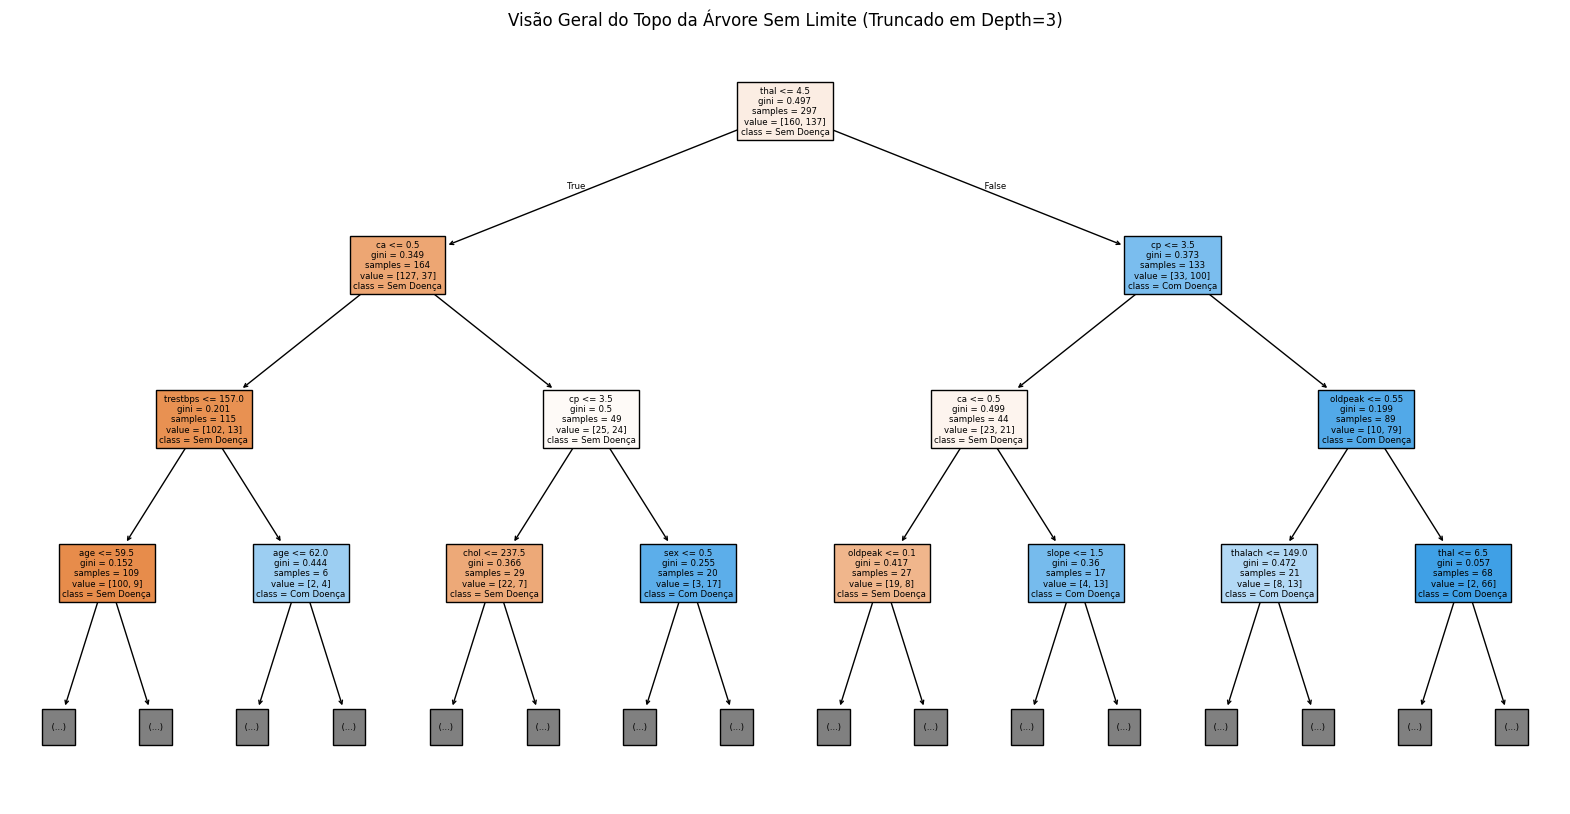

In [6]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_unlimited,
    feature_names=X.columns,
    class_names=['Sem Doença', 'Com Doença'],
    filled=True,
    max_depth=3 # Exibindo apenas os 3 primeiros níveis para visualização não poluir
)
plt.title("Visão Geral do Topo da Árvore Sem Limite (Truncado em Depth=3)")
plt.show()

=== COMPARATIVO DE ESTRUTURA E PROBABILIDADES ===
Árvore Sem Limite (Depth=11):
  - Total de folhas: 57
  - Probabilidades únicas geradas nas folhas: [0. 1.]

Árvore Limitada (max_depth=3):
  - Total de folhas: 8
  - Probabilidades únicas geradas nas folhas: [0.083 0.241 0.296 0.619 0.667 0.765 0.85  0.971]


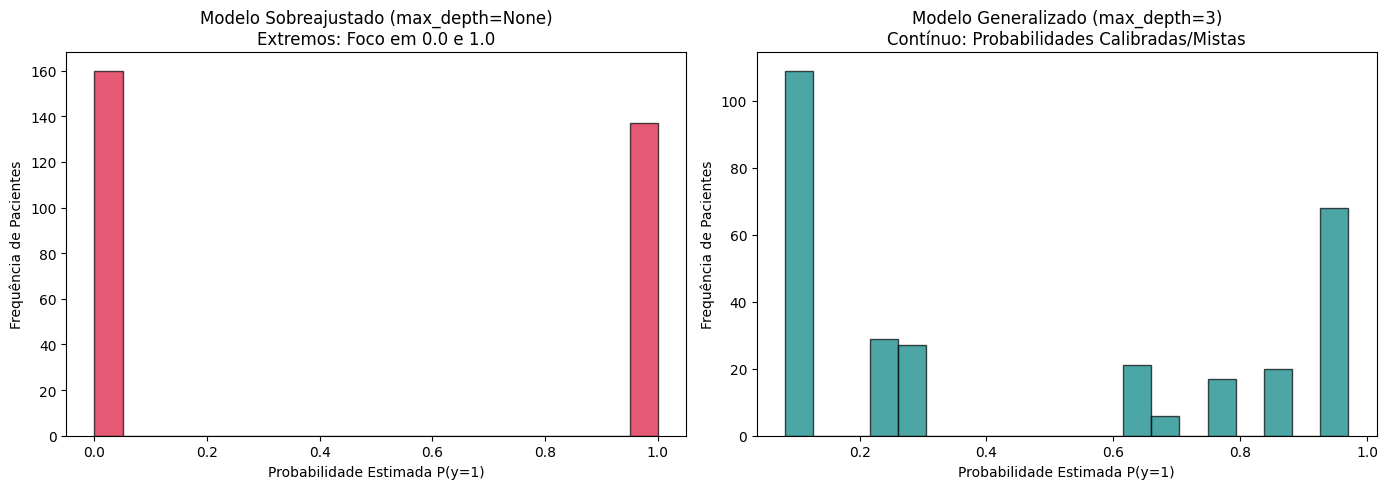

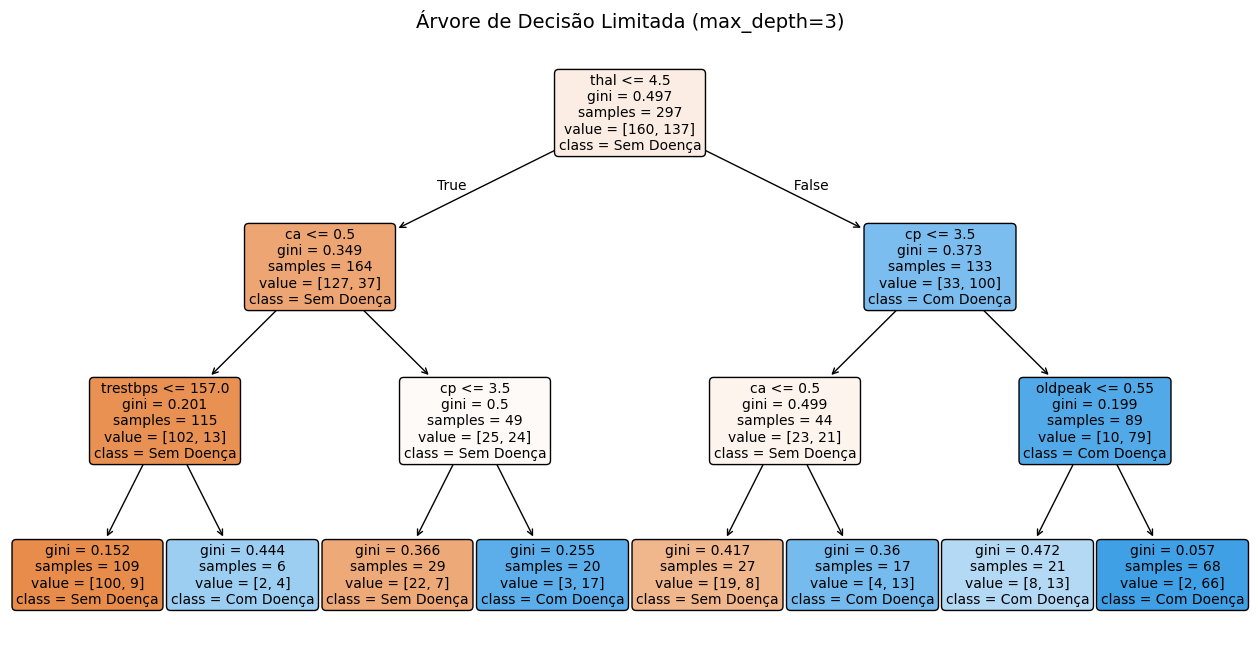

In [7]:
# 1. Instanciar e treinar a árvore limitada (max_depth=3)
dt_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_limited.fit(X, y)

# 2. Obter as probabilidades estimadas para cada paciente em ambos os modelos
# predict_proba retorna [P(y=0), P(y=1)] para cada amostra
prob_unlimited = dt_unlimited.predict_proba(X)[:, 1] # Probabilidade da classe 1 (Doença)
prob_limited = dt_limited.predict_proba(X)[:, 1]

# 3. Analisar a diversidade de probabilidades estimadas em cada modelo
unique_probs_unlimited = np.unique(prob_unlimited)
unique_probs_limited = np.unique(prob_limited)

print("=== COMPARATIVO DE ESTRUTURA E PROBABILIDADES ===")
print(f"Árvore Sem Limite (Depth={dt_unlimited.get_depth()}):")
print(f"  - Total de folhas: {dt_unlimited.get_n_leaves()}")
print(f"  - Probabilidades únicas geradas nas folhas: {np.round(unique_probs_unlimited, 3)}")

print(f"\nÁrvore Limitada (max_depth=3):")
print(f"  - Total de folhas: {dt_limited.get_n_leaves()}")
print(f"  - Probabilidades únicas geradas nas folhas: {np.round(unique_probs_limited, 3)}")

# 4. Visualizar a distribuição comparativa das probabilidades estimadas
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(prob_unlimited, bins=20, color='crimson', edgecolor='black', alpha=0.7)
plt.title("Modelo Sobreajustado (max_depth=None)\nExtremos: Foco em 0.0 e 1.0")
plt.xlabel("Probabilidade Estimada P(y=1)")
plt.ylabel("Frequência de Pacientes")

plt.subplot(1, 2, 2)
plt.hist(prob_limited, bins=20, color='teal', edgecolor='black', alpha=0.7)
plt.title("Modelo Generalizado (max_depth=3)\nContínuo: Probabilidades Calibradas/Mistas")
plt.xlabel("Probabilidade Estimada P(y=1)")
plt.ylabel("Frequência de Pacientes")

plt.tight_layout()
plt.show()

# 5. Visualizar a estrutura da Árvore Limitada (ideal para o Relatório)
plt.figure(figsize=(16, 8))
plot_tree(
    dt_limited,
    feature_names=X.columns,
    class_names=['Sem Doença', 'Com Doença'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árvore de Decisão Limitada (max_depth=3)", fontsize=14)
plt.show()